# MRI to Synthetic PET 

## Import Dependancies

In [ ]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "torch", "torchvision", "numpy", "matplotlib",
                "scikit-image", "optuna"], check=False)

import os, glob, random, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.ndimage import rotate as scipy_rotate, map_coordinates, gaussian_filter
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

## Configuration

In [2]:
DATA_ROOT    = "/workspace/Data/NACC_Combined_AUG"

SAVE_PATH    = "/workspace/Outputs/mri2pet_v3_improved/best_ssim_model.pt"   # saved by SSIM
SAVE_LOSS    = "/workspace/Outputs/mri2pet_v3_improved/best_loss_model.pt"   # saved by loss (just for backup)
CKPT_PATH    = "/workspace/Outputs/mri2pet_v3_improved/resume_ckpt.pt"
SAMPLE_DIR   = "/workspace/Outputs/mri2pet_v3_improved/training_samples"
HPO_DIR      = "/workspace/Outputs/mri2pet_v3_improved/hpo_study"

PATCH_SIZE   = 64
BATCH_SIZE   = 2
EPOCHS       = 350
SAMPLE_EVERY = 5
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"

N_TRIALS     = 20           # more trials to explore sharper loss space
HPO_EPOCHS   = 12

for d in [SAMPLE_DIR, HPO_DIR,
          os.path.dirname(SAVE_PATH)]:
    os.makedirs(d, exist_ok=True)

print(f"Device: {DEVICE}")

Device: cuda


## Normalisation

In [3]:
def norm_mri(v):
    """MRI: percentile robust normalisation → [0, 1]."""
    lo, hi = np.percentile(v, 1), np.percentile(v, 99)
    return np.clip((v - lo) / (hi - lo + 1e-8), 0, 1).astype(np.float32)


def norm_pet(v):
    """PET: SUV-normalisation — divide by mean foreground uptake.
    Foreground = voxels above 5% of max (cheap proxy for brain mask).
    Result clipped to [0, 2] then scaled to [0, 1] for network input.
    """
    fg_mask = v > (v.max() * 0.05 + 1e-8)
    mean_uptake = v[fg_mask].mean() if fg_mask.any() else 1.0
    suv = v / (mean_uptake + 1e-8)
    return np.clip(suv / 2.0, 0, 1).astype(np.float32)   # /2 puts typical SUV≤2 into [0,1]




def compute_brain_mask(mri_norm, threshold=0.1):
    """
    Fast brain mask from normalised MRI: any voxel brighter than
    `threshold` is considered brain/skull tissue.
    Morphological closing (binary dilation×3) fills small holes.
    Returns a bool array, same shape as mri_norm.
    """
    from scipy.ndimage import binary_dilation, binary_erosion
    mask = mri_norm > threshold
    # 3 rounds of dilation then 3 of erosion → closing
    for _ in range(3):
        mask = binary_dilation(mask)
    for _ in range(3):
        mask = binary_erosion(mask)
    return mask.astype(bool)


# ── 3-D Augmentation suite ────────────────────────────────────
class Augment3D:
    """
    All operations are applied *identically* to the MRI and PET pair
    so spatial correspondence is preserved.
    Intensity-only ops (gamma, noise, contrast) are MRI-only because
    they simulate scanner variation, not anatomy.
    """

    # ── spatial ──────────────────────────────────────────────
    @staticmethod
    def flip(mri, pet):
        """Random axis flip."""
        for ax in range(3):
            if random.random() > 0.5:
                mri = np.flip(mri, axis=ax).copy()
                pet = np.flip(pet, axis=ax).copy()
        return mri, pet

    @staticmethod
    def rotate90(mri, pet):
        """Random 0/90/180/270° rotation in the axial plane."""
        k = random.randint(0, 3)
        if k:
            mri = np.rot90(mri, k=k, axes=(1, 2)).copy()
            pet = np.rot90(pet, k=k, axes=(1, 2)).copy()
        return mri, pet

    @staticmethod
    def rotate_small(mri, pet, max_angle=10):
        """Small continuous rotation around z-axis."""
        angle = random.uniform(-max_angle, max_angle)
        mri = scipy_rotate(mri, angle, axes=(1, 2), reshape=False, order=1, mode='nearest')
        pet = scipy_rotate(pet, angle, axes=(1, 2), reshape=False, order=1, mode='nearest')
        return mri.astype(np.float32), pet.astype(np.float32)

    @staticmethod
    def zoom(mri, pet, lo=0.9, hi=1.1):
        """Uniform random zoom (crop/pad to keep patch size)."""
        factor = random.uniform(lo, hi)
        D, H, W = mri.shape
        nD, nH, nW = int(D * factor), int(H * factor), int(W * factor)
        def _zoom_vol(v, nD, nH, nW):
            from skimage.transform import resize
            return resize(v, (nD, nH, nW), order=1, mode='reflect',
                          anti_aliasing=False, preserve_range=True).astype(np.float32)
        mri_z = _zoom_vol(mri, nD, nH, nW)
        pet_z = _zoom_vol(pet, nD, nH, nW)
        def _centre_crop(v, D, H, W):
            d0 = max(0, (v.shape[0] - D) // 2); d1 = d0 + D
            h0 = max(0, (v.shape[1] - H) // 2); h1 = h0 + H
            w0 = max(0, (v.shape[2] - W) // 2); w1 = w0 + W
            out = np.zeros((D, H, W), dtype=np.float32)
            sd = min(d1, v.shape[0]) - d0; sh = min(h1, v.shape[1]) - h0; sw = min(w1, v.shape[2]) - w0
            out[:sd, :sh, :sw] = v[d0:d0+sd, h0:h0+sh, w0:w0+sw]
            return out
        return _centre_crop(mri_z, D, H, W), _centre_crop(pet_z, D, H, W)

    @staticmethod
    def elastic(mri, pet, alpha=8, sigma=3):
        """Elastic deformation (Simard et al.)."""
        shape = mri.shape
        dx = gaussian_filter(np.random.randn(*shape).astype(np.float32), sigma) * alpha
        dy = gaussian_filter(np.random.randn(*shape).astype(np.float32), sigma) * alpha
        dz = gaussian_filter(np.random.randn(*shape).astype(np.float32), sigma) * alpha
        x, y, z = np.meshgrid(np.arange(shape[0]), np.arange(shape[1]),
                               np.arange(shape[2]), indexing='ij')
        coords = [np.clip(x+dx, 0, shape[0]-1),
                  np.clip(y+dy, 0, shape[1]-1),
                  np.clip(z+dz, 0, shape[2]-1)]
        mri_e = map_coordinates(mri, coords, order=1, mode='nearest').astype(np.float32)
        pet_e = map_coordinates(pet, coords, order=1, mode='nearest').astype(np.float32)
        return mri_e, pet_e

    # ── intensity (MRI only) ─────────────────────────────────
    @staticmethod
    def gamma(mri, lo=0.7, hi=1.5):
        g = random.uniform(lo, hi)
        return np.power(np.clip(mri, 1e-6, 1), g).astype(np.float32)

    @staticmethod
    def contrast_jitter(mri, lo=0.8, hi=1.2):
        factor = random.uniform(lo, hi)
        mean   = mri.mean()
        return np.clip((mri - mean) * factor + mean, 0, 1).astype(np.float32)

    @staticmethod
    def gaussian_noise(mri, std_max=0.02):
        std = random.uniform(0, std_max)
        return np.clip(mri + np.random.randn(*mri.shape).astype(np.float32) * std, 0, 1)

    @staticmethod
    def bias_field(mri, order=3):
        D, H, W = mri.shape
        coords = np.mgrid[0:D, 0:H, 0:W].astype(np.float32)
        for i, s in enumerate([D, H, W]):
            coords[i] = coords[i] / (s - 1) * 2 - 1
        field = np.ones((D, H, W), dtype=np.float32)
        for _ in range(order):
            axis  = random.randint(0, 2)
            coeff = random.uniform(-0.1, 0.1)
            field += coeff * coords[axis]
        field = np.clip(field, 0.8, 1.2)
        return np.clip(mri * field, 0, 1).astype(np.float32)


def augment_pair(mri, pet):
    """Apply the full augmentation pipeline to an (mri, pet) pair."""
    aug = Augment3D
    mri, pet = aug.flip(mri, pet)
    mri, pet = aug.rotate90(mri, pet)
    if random.random() < 0.5:
        mri, pet = aug.rotate_small(mri, pet)
    if random.random() < 0.4:
        mri, pet = aug.zoom(mri, pet)
    if random.random() < 0.3:
        mri, pet = aug.elastic(mri, pet)
    if random.random() < 0.5:
        mri = aug.gamma(mri)
    if random.random() < 0.5:
        mri = aug.contrast_jitter(mri)
    if random.random() < 0.4:
        mri = aug.gaussian_noise(mri)
    if random.random() < 0.3:
        mri = aug.bias_field(mri)
    return mri, pet

print("Normalisation (MRI percentile + PET SUV-based), brain mask, and augmentation suite ready.")


Normalisation (MRI percentile + PET SUV-based), brain mask, and augmentation suite ready.


## Dataset

In [4]:
class PETDataset(Dataset):
    def __init__(self, pairs, train=True, patch_size=PATCH_SIZE):
        self.pairs      = pairs
        self.train      = train
        self.patch_size = patch_size

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        mri_path, pet_path = self.pairs[idx]
        mri = norm_mri(np.load(mri_path))
        pet = norm_pet(np.load(pet_path))   # SUV-based normalisation

        D, H, W = mri.shape
        p = self.patch_size
        x = random.randint(0, D-p); y = random.randint(0, H-p); z = random.randint(0, W-p)
        mri = mri[x:x+p, y:y+p, z:z+p]
        pet = pet[x:x+p, y:y+p, z:z+p]

        if self.train:
            mri, pet = augment_pair(mri, pet)

        return (torch.from_numpy(mri.copy()).unsqueeze(0),
                torch.from_numpy(pet.copy()).unsqueeze(0))


# Patient-level split (prevents data leakage)
# 1. Build a dict: patient_id -> list of (mri_path, pet_path)
from collections import defaultdict
patient_pairs = defaultdict(list)

for folder in sorted(os.listdir(DATA_ROOT)):
    fd  = os.path.join(DATA_ROOT, folder)
    mri = os.path.join(fd, "mri_processed.npy")
    pet = os.path.join(fd, "pet_processed.npy")
    if not (os.path.isdir(fd) and os.path.isfile(mri) and os.path.isfile(pet)):
        continue
    # Extract base patient ID: strip _orig / _aug_XXXX suffix
    if folder.endswith("_orig"):
        pid = folder[:-5]                      # remove '_orig'
    elif "_aug_" in folder:
        pid = folder[:folder.index("_aug_")]   # keep everything before '_aug_'
    else:
        pid = folder                           # plain original folder (fallback)
    patient_pairs[pid].append((mri, pet))

# 2. Split patient IDs 80 / 10 / 10
patient_ids = sorted(patient_pairs.keys())
random.seed(42)
random.shuffle(patient_ids)
n_total = len(patient_ids)
n_tr    = int(n_total * 0.8)
n_va    = int(n_total * 0.1)

tr_ids = patient_ids[:n_tr]
va_ids = patient_ids[n_tr:n_tr+n_va]
te_ids = patient_ids[n_tr+n_va:]

# 3. Collect all pairs belonging to each split
tr_pairs = [p for pid in tr_ids for p in patient_pairs[pid]]
va_pairs = [p for pid in va_ids for p in patient_pairs[pid]]
te_pairs = [p for pid in te_ids for p in patient_pairs[pid]]

print(f"Patients  : {n_total} total  ({len(tr_ids)} train / {len(va_ids)} val / {len(te_ids)} test)")
print(f"Pairs     : {len(tr_pairs)} train  {len(va_pairs)} val  {len(te_pairs)} test")
print(f"Avg pairs/patient in train: {len(tr_pairs)/max(len(tr_ids),1):.1f}")

# 4. For val/test, disable online augmentation (data_leakage_free=True means augmented variants are already pre-generated offline).
train_loader = DataLoader(PETDataset(tr_pairs, train=True),  batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(PETDataset(va_pairs, train=False), batch_size=1,          shuffle=False, num_workers=2)

print(f"\nDataLoaders ready.")

Patients  : 259 total  (207 train / 25 val / 27 test)
Pairs     : 1863 train  225 val  243 test
Avg pairs/patient in train: 9.0

DataLoaders ready.


## Attention U-Net (3-D) Model

In [5]:
def gn(c, groups=8):
    """GroupNorm; falls back to fewer groups if channels < 8."""
    g = min(groups, c)
    while c % g != 0:
        g //= 2
    return nn.GroupNorm(g, c)


def block(ic, oc):
    return nn.Sequential(
        nn.Conv3d(ic, oc, 3, padding=1), gn(oc), nn.LeakyReLU(0.1, inplace=True),
        nn.Conv3d(oc, oc, 3, padding=1), gn(oc), nn.LeakyReLU(0.1, inplace=True),
    )


class AttentionGate(nn.Module):
    """
    Soft-attention gate (Oktay et al., 2018).
    g  : gating signal from the decoder  (coarser resolution, upsampled to match x)
    x  : skip-connection feature map     (encoder, same resolution as output)
    Returns x scaled by learned spatial attention weights in [0, 1].
    """
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Sequential(nn.Conv3d(F_g, F_int, 1, bias=True), gn(F_int))
        self.W_x = nn.Sequential(nn.Conv3d(F_l, F_int, 1, bias=True), gn(F_int))
        self.psi = nn.Sequential(nn.Conv3d(F_int, 1, 1, bias=True), nn.Sigmoid())
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        # Upsample g to match x spatial size
        g_up = F.interpolate(g, size=x.shape[2:], mode='trilinear', align_corners=False)
        att  = self.psi(self.relu(self.W_g(g_up) + self.W_x(x)))
        return x * att


class UNet(nn.Module):
    def __init__(self, base=32):
        super().__init__()
        b = base
        # Encoder
        self.e1  = block(1,   b)
        self.e2  = block(b,   b*2)
        self.e3  = block(b*2, b*4)
        self.bn  = block(b*4, b*8)
        # Attention gates
        self.ag3 = AttentionGate(b*8, b*4, b*2)
        self.ag2 = AttentionGate(b*4, b*2, b)
        self.ag1 = AttentionGate(b*2, b,   b//2)
        # Decoder
        self.d3  = block(b*8 + b*4, b*4)
        self.d2  = block(b*4 + b*2, b*2)
        self.d1  = block(b*2 + b,   b)
        self.out = nn.Conv3d(b, 1, 1)
        self.pool = nn.MaxPool3d(2)
        self.up   = nn.Upsample(scale_factor=2, mode='trilinear', align_corners=False)

    def forward(self, x):
        s1  = self.e1(x)
        s2  = self.e2(self.pool(s1))
        s3  = self.e3(self.pool(s2))
        btm = self.bn(self.pool(s3))
        # Decode with attention-gated skips
        s3a = self.ag3(btm, s3)
        x   = self.d3(torch.cat([self.up(btm), s3a], 1))
        s2a = self.ag2(x, s2)
        x   = self.d2(torch.cat([self.up(x), s2a], 1))
        s1a = self.ag1(x, s1)
        x   = self.d1(torch.cat([self.up(x), s1a], 1))
        return torch.sigmoid(self.out(x))


model = UNet().to(DEVICE)
n = sum(p.numel() for p in model.parameters())
print(f"Attention U-Net — base=32 — params: {n/1e6:.1f}M")


Attention U-Net — base=32 — params: 5.9M


## Triple Loss Function: L1 + 3-D SSIM + Gradient-Difference Loss

In [6]:
# 3-D SSIM (unchanged from v1)
def gaussian_kernel_3d(size=7, sigma=1.5, device='cpu'):
    coords = torch.arange(size, dtype=torch.float32, device=device) - size // 2
    g1d    = torch.exp(-coords**2 / (2 * sigma**2))
    g1d    = g1d / g1d.sum()
    kernel = g1d[:, None, None] * g1d[None, :, None] * g1d[None, None, :]
    return kernel.unsqueeze(0).unsqueeze(0)

_KERNEL = None

def ssim_loss(pred, target, kernel_size=7, sigma=1.5, C1=1e-4, C2=9e-4):
    global _KERNEL
    if _KERNEL is None or _KERNEL.device != pred.device:
        _KERNEL = gaussian_kernel_3d(kernel_size, sigma, pred.device)
    pad    = kernel_size // 2
    mu1    = F.conv3d(pred,   _KERNEL, padding=pad)
    mu2    = F.conv3d(target, _KERNEL, padding=pad)
    mu1sq, mu2sq, mu12 = mu1**2, mu2**2, mu1 * mu2
    sig1sq = F.conv3d(pred   * pred,   _KERNEL, padding=pad) - mu1sq
    sig2sq = F.conv3d(target * target, _KERNEL, padding=pad) - mu2sq
    sig12  = F.conv3d(pred   * target, _KERNEL, padding=pad) - mu12
    num    = (2 * mu12  + C1) * (2 * sig12  + C2)
    den    = (mu1sq + mu2sq + C1) * (sig1sq + sig2sq + C2)
    return 1.0 - (num / den).mean()


# Gradient Difference Loss (GDL) 
def gdl_loss(pred, target, alpha_gdl=2):
    def grad(v, dim):
        # Simple finite-difference gradient along dim (D=2, H=3, W=4)
        return v.narrow(dim, 1, v.shape[dim]-1) - v.narrow(dim, 0, v.shape[dim]-1)

    loss = 0.0
    for dim in (2, 3, 4):
        gp = grad(pred,   dim)
        gt = grad(target, dim)
        loss += (torch.abs(torch.abs(gp) - torch.abs(gt)) ** alpha_gdl).mean()
    return loss / 3.0


# Combined triple loss
def combined_loss(pred, target, lam_l1=0.15, lam_ssim=0.55, lam_gdl=0.30):
    """
    lam_l1   : weight for L1 reconstruction loss
    lam_ssim : weight for 1 - SSIM  (maximise SSIM)
    lam_gdl  : weight for Gradient Difference Loss (sharpness)
    Sum of weights should be 1.0.
    """
    l1   = F.l1_loss(pred, target)
    ssim = ssim_loss(pred, target)
    gdl  = gdl_loss(pred, target)
    return lam_l1 * l1 + lam_ssim * ssim + lam_gdl * gdl


print("Triple loss (L1 + SSIM + GDL) ready.")
print("Default weights: L1=0.15  SSIM=0.55  GDL=0.30")


Triple loss (L1 + SSIM + GDL) ready.
Default weights: L1=0.15  SSIM=0.55  GDL=0.30


## Helper Functions


In [7]:
def pad8(v):
    pad = [(0, (8 - s % 8) % 8) for s in v.shape]
    return np.pad(v, pad, mode='constant')


def _single_pass_infer(model, mri_np, patch=PATCH_SIZE, overlap=0.5):
    """Core sliding-window inference (one orientation)."""
    model.eval()
    D, H, W   = mri_np.shape
    step      = max(1, int(patch * (1 - overlap)))
    win1d     = np.hanning(patch).astype(np.float32) + 1e-6
    win3d     = win1d[:, None, None] * win1d[None, :, None] * win1d[None, None, :]

    pad_d = (patch - D % patch) % patch
    pad_h = (patch - H % patch) % patch
    pad_w = (patch - W % patch) % patch
    mri_p = np.pad(mri_np, ((0, pad_d), (0, pad_h), (0, pad_w)), mode='reflect')
    PD, PH, PW = mri_p.shape
    out_p = np.zeros((PD, PH, PW), dtype=np.float32)
    wgt_p = np.zeros((PD, PH, PW), dtype=np.float32)

    xs = list(range(0, PD - patch + 1, step)) or [0]
    ys = list(range(0, PH - patch + 1, step)) or [0]
    zs = list(range(0, PW - patch + 1, step)) or [0]
    if xs[-1] + patch < PD: xs.append(PD - patch)
    if ys[-1] + patch < PH: ys.append(PH - patch)
    if zs[-1] + patch < PW: zs.append(PW - patch)

    with torch.no_grad():
        for x in xs:
            for y in ys:
                for z in zs:
                    patch_np = mri_p[x:x+patch, y:y+patch, z:z+patch]
                    t = torch.from_numpy(patch_np).unsqueeze(0).unsqueeze(0).to(DEVICE)
                    pred = model(t)[0, 0].cpu().numpy()
                    out_p[x:x+patch, y:y+patch, z:z+patch] += pred * win3d
                    wgt_p[x:x+patch, y:y+patch, z:z+patch] += win3d

    result = (out_p / (wgt_p + 1e-8))[:D, :H, :W]
    torch.cuda.empty_cache()
    return result.astype(np.float32)


def sliding_window_infer(model, mri_np, patch=PATCH_SIZE, overlap=0.5, tta=True):
    if not tta:
        return _single_pass_infer(model, mri_np, patch, overlap)

    accumulator = np.zeros_like(mri_np, dtype=np.float32)
    flip_axes_list = [
        [],        # no flip (original)
        [0],       # flip D
        [1],       # flip H
        [2],       # flip W
        [0, 1],    # flip D+H
        [0, 2],    # flip D+W
        [1, 2],    # flip H+W
        [0, 1, 2], # flip all
    ]

    for axes in flip_axes_list:
        aug_mri = mri_np.copy()
        for ax in axes:
            aug_mri = np.flip(aug_mri, axis=ax)
        pred = _single_pass_infer(model, np.ascontiguousarray(aug_mri), patch, overlap)
        # Reverse the flips on the prediction
        for ax in axes:
            pred = np.flip(pred, axis=ax)
        accumulator += np.ascontiguousarray(pred)

    return (accumulator / len(flip_axes_list)).astype(np.float32)


# ── Masked SSIM helper ────────────────────────────────────────
def masked_ssim_slice(gt_slice, pred_slice, mask_slice, data_range=1.0):
    """
    Compute SSIM restricted to the brain mask region on a 2-D slice.
    Falls back to full-image SSIM if the mask is too small (< 100 voxels).
    """
    from skimage.metrics import structural_similarity as sk_ssim
    if mask_slice.sum() < 100:
        return float(sk_ssim(gt_slice, pred_slice, data_range=data_range))
    # Zero out background so SSIM is dominated by brain tissue
    gt_m   = gt_slice   * mask_slice
    pred_m = pred_slice * mask_slice
    return float(sk_ssim(gt_m, pred_m, data_range=data_range))


def compute_masked_metrics(syn, gt, mask):
    """
    Compute MAE / MSE / SSIM (both global and brain-masked)
    """
    from skimage.metrics import structural_similarity as sk_ssim

    # Global (full volume)
    mae_g  = float(np.mean(np.abs(syn - gt)))
    mse_g  = float(np.mean((syn - gt)**2))
    ssim_g = float(np.mean([sk_ssim(gt[i], syn[i], data_range=1.0)
                             for i in range(gt.shape[0])]))

    # Brain-masked
    syn_m = syn[mask]; gt_m = gt[mask]
    mae_m  = float(np.mean(np.abs(syn_m - gt_m)))
    mse_m  = float(np.mean((syn_m - gt_m)**2))
    ssim_m = float(np.mean([masked_ssim_slice(gt[i], syn[i], mask[i])
                             for i in range(gt.shape[0])]))

    return {
        'MAE':       mae_g,  'MSE':       mse_g,  'SSIM':       ssim_g,
        'MAE_brain': mae_m,  'MSE_brain': mse_m,  'SSIM_brain': ssim_m,
    }

def save_sample_png(model, mri_path, pet_path, epoch, out_dir):
    torch.cuda.empty_cache()
    mri_np = norm_mri(np.load(mri_path))
    pet_np = norm_pet(np.load(pet_path))
    syn_np = sliding_window_infer(model, mri_np, tta=False)  # fast during training

    mid = mri_np.shape[0] // 2
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(mri_np[mid], cmap='gray');  axes[0].set_title('MRI');       axes[0].axis('off')
    axes[1].imshow(pet_np[mid], cmap='hot');   axes[1].set_title('True PET'); axes[1].axis('off')
    axes[2].imshow(syn_np[mid], cmap='hot');   axes[2].set_title('Synth PET (TTA)'); axes[2].axis('off')

    sid = os.path.basename(os.path.dirname(mri_path))
    plt.suptitle(f'Epoch {epoch:03d}  |  {sid}', fontsize=10)
    plt.tight_layout()
    png_path = os.path.join(out_dir, f'epoch_{epoch:03d}_{sid}.png')
    plt.savefig(png_path, dpi=120, bbox_inches='tight')
    plt.close(fig)
    return png_path


SAMPLE_MRI, SAMPLE_PET = va_pairs[0]
print(f"Sample subject: {os.path.basename(os.path.dirname(SAMPLE_MRI))}")

Sample subject: NACC005483_aug_0001


## Hyperparameters 


In [8]:
# import optuna
# storage_url = f"sqlite:///{HPO_DIR}/optuna.db"
# study_name = "mri2pet_hpo"
# try:
#     all_studies = optuna.study.get_all_study_names(storage_url)
#     study = optuna.load_study(study_name=study_name, storage=storage_url)
#     print(f"Loaded '{study_name}' with {len(study.trials)} trials")
# except KeyError:
#     study = optuna.create_study(
#         direction='maximize', study_name=study_name, storage=storage_url,
#         sampler=optuna.samplers.TPESampler(seed=42),
#         pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2)
#     )

print('HPO skipped — pre-tuned params will be used in the training cell below.')


HPO skipped — pre-tuned params will be used in the training cell below.


In [9]:
# import optuna
# print('STUDIES IN DB:', optuna.study.get_all_study_names(f'sqlite:///{HPO_DIR}/optuna.db'))
# ── Skipped: no active study object ──


In [10]:
from skimage.metrics import structural_similarity as sk_ssim

def val_ssim(model, va_pairs, n_subjects=5):
    """ Quick full-volume brain-masked SSIM estimate on validation subjects. """
    model.eval()
    scores = []
    subset = va_pairs[:n_subjects] if len(va_pairs) >= n_subjects else va_pairs
    for mri_path, pet_path in subset:
        mri_np = norm_mri(np.load(mri_path))
        pet_np = norm_pet(np.load(pet_path))
        brain_mask = compute_brain_mask(mri_np)
        syn_np = sliding_window_infer(model, mri_np, tta=False)   # fast
        # Brain-masked SSIM: zero background before computing SSIM
        s = float(np.mean([masked_ssim_slice(pet_np[i], syn_np[i], brain_mask[i])
                           for i in range(pet_np.shape[0])]))
        scores.append(s)
    return float(np.mean(scores))


# ── One-trial training function ───────────────────────────────
def run_trial(lr, weight_decay, lam_l1, lam_gdl, base,
              scheduler_type, batch_size, epochs, tr_pairs, va_pairs):
    """Train a fresh model with given hyperparams; return best val SSIM."""
    lam_ssim = max(0.05, 1.0 - lam_l1 - lam_gdl)   # derived weight

    _model  = UNet(base=base).to(DEVICE)
    _opt    = torch.optim.AdamW(_model.parameters(), lr=lr, weight_decay=weight_decay)
    _scaler = torch.amp.GradScaler('cuda')

    if scheduler_type == 'cosine':
        _sched = torch.optim.lr_scheduler.CosineAnnealingLR(_opt, T_max=epochs)
    elif scheduler_type == 'warmup_cosine':
        warmup = max(1, epochs // 10)
        _sched = torch.optim.lr_scheduler.SequentialLR(
            _opt,
            schedulers=[
                torch.optim.lr_scheduler.LinearLR(_opt, start_factor=0.1, total_iters=warmup),
                torch.optim.lr_scheduler.CosineAnnealingLR(_opt, T_max=epochs - warmup)
            ],
            milestones=[warmup]
        )
    else:
        _sched = None

    _loader = DataLoader(
        PETDataset(tr_pairs, train=True),
        batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True
    )

    best_ssim = 0.0
    for epoch in range(1, epochs + 1):
        _model.train()
        for mri, pet in _loader:
            mri, pet = mri.to(DEVICE), pet.to(DEVICE)
            _opt.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda'):
                loss = combined_loss(_model(mri), pet,
                                     lam_l1=lam_l1, lam_ssim=lam_ssim, lam_gdl=lam_gdl)
            _scaler.scale(loss).backward()
            # Gradient clipping for stability
            _scaler.unscale_(_opt)
            torch.nn.utils.clip_grad_norm_(_model.parameters(), max_norm=1.0)
            _scaler.step(_opt); _scaler.update()
        if _sched: _sched.step()

        if epoch % 4 == 0 or epoch == epochs:
            s = val_ssim(_model, va_pairs)
            if s > best_ssim:
                best_ssim = s

    del _model, _opt, _scaler, _loader
    torch.cuda.empty_cache()
    return best_ssim


# Optuna objective 
def objective(trial):
    lr           = trial.suggest_float('lr',           5e-5,  5e-4,  log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6,  5e-3,  log=True)
    lam_l1       = trial.suggest_float('lam_l1',       0.05,  0.25)
    lam_gdl      = trial.suggest_float('lam_gdl',      0.10,  0.45)
    base         = trial.suggest_categorical('base',         [32, 48, 64])
    scheduler    = trial.suggest_categorical('scheduler',    ['cosine', 'warmup_cosine'])
    batch_size   = trial.suggest_categorical('batch_size',   [2, 4])

    # Prune invalid weight combinations
    if lam_l1 + lam_gdl > 0.90:
        raise optuna.exceptions.TrialPruned()  # lam_ssim would be < 0.10

    return run_trial(
        lr=lr, weight_decay=weight_decay,
        lam_l1=lam_l1, lam_gdl=lam_gdl,
        base=base, scheduler_type=scheduler,
        batch_size=batch_size, epochs=HPO_EPOCHS,
        tr_pairs=tr_pairs, va_pairs=va_pairs
    )


# print(f'Starting Optuna HPO: {N_TRIALS} trials x {HPO_EPOCHS} epochs each')
# study = optuna.create_study(
#     direction='maximize', study_name='mri2pet_hpo_v2',
#     storage=f'sqlite:///{HPO_DIR}/optuna_v2.db', load_if_exists=True,
#     sampler=optuna.samplers.TPESampler(seed=42),
#     pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
# )
# study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print('HPO skipped. val_ssim() and run_trial() are defined above for future use.')


HPO skipped. val_ssim() and run_trial() are defined above for future use.


In [12]:
# import pandas as pd
# trials_df = study.trials_dataframe()
# print('Pandas working! Shape:', trials_df.shape)

## HPO Visualisation 

In [13]:
# import pandas as pd
# %matplotlib inline
# trials_df = study.trials_dataframe()
# fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# axes[0].plot(trials_df['number'], trials_df['value'], 'o-', ms=4)
# axes[0].axhline(study.best_value, color='red', ls='--', label=f'Best={study.best_value:.3f}')
# axes[0].set_xlabel('Trial'); axes[0].set_ylabel('Val SSIM')
# axes[0].set_title('HPO Trial History'); axes[0].legend(); axes[0].grid(alpha=0.3)
# plt.tight_layout(); plt.show()

print('HPO visualisation skipped.')


HPO visualisation skipped.


## Final Training with Best Hyperparameters

Uses the best config found by Optuna for the full `EPOCHS` budget, with resume-from-checkpoint support.

In [14]:
# Hardcoded best params from previous Optuna run 
BEST_LR    = 0.00023000520341708258
BEST_WD    = 0.00018277373056108833
BEST_BASE  = 16          # UNet base channels
BEST_SCHED = 'cosine'
BEST_BS    = 2

# Loss weights — v2 defaults (alpha=0.87 from old HPO doesn't map here)
BEST_L1   = 0.15
BEST_GDL  = 0.30
BEST_SSIM = max(0.05, 1.0 - BEST_L1 - BEST_GDL)  # 0.55

print('Final training config (pre-tuned):')
print(f'  lr           = {BEST_LR}')
print(f'  weight_decay = {BEST_WD}')
print(f'  base         = {BEST_BASE}')
print(f'  scheduler    = {BEST_SCHED}')
print(f'  batch_size   = {BEST_BS}')
print(f'  lam_l1       = {BEST_L1}')
print(f'  lam_ssim     = {BEST_SSIM}  (derived)')
print(f'  lam_gdl      = {BEST_GDL}')

model     = UNet(base=BEST_BASE).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=BEST_LR, weight_decay=BEST_WD)
scaler    = torch.amp.GradScaler('cuda')

if BEST_SCHED == 'cosine':
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
elif BEST_SCHED == 'warmup_cosine':
    warmup_ep = max(5, EPOCHS // 15)
    scheduler = torch.optim.lr_scheduler.SequentialLR(
        optimizer,
        schedulers=[
            torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.05,
                                              total_iters=warmup_ep),
            torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,
                                                        T_max=EPOCHS - warmup_ep)
        ],
        milestones=[warmup_ep]
    )
else:
    scheduler = None

final_train_loader = DataLoader(
    PETDataset(tr_pairs, train=True),
    batch_size=BEST_BS, shuffle=True, num_workers=4, pin_memory=True
)

train_losses, val_losses, val_ssims = [], [], []
best_val   = float('inf')
best_ssim  = 0.0
start_epoch = 1

# Resume from checkpoint 
if os.path.isfile(CKPT_PATH):
    print(f'\nResuming from {CKPT_PATH}')
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scaler.load_state_dict(ckpt['scaler_state'])
    train_losses = ckpt['train_losses']
    val_losses   = ckpt['val_losses']
    val_ssims    = ckpt.get('val_ssims', [])
    best_val     = ckpt['best_val']
    best_ssim    = ckpt.get('best_ssim', 0.0)
    start_epoch  = ckpt['epoch'] + 1
    print(f'   Resumed at epoch {start_epoch}  (best SSIM = {best_ssim:.4f})')
else:
    print('No checkpoint — starting fresh.')

n = sum(p.numel() for p in model.parameters())
print(f'Model params: {n/1e6:.1f}M')


Final training config (pre-tuned):
  lr           = 0.00023000520341708258
  weight_decay = 0.00018277373056108833
  base         = 16
  scheduler    = cosine
  batch_size   = 2
  lam_l1       = 0.15
  lam_ssim     = 0.55  (derived)
  lam_gdl      = 0.3

Resuming from /workspace/Outputs/mri2pet_v3_improved/resume_ckpt.pt
   Resumed at epoch 351  (best SSIM = 0.7948)
Model params: 1.5M


# Full training loop

In [15]:
for epoch in range(start_epoch, EPOCHS + 1):
    model.train()
    tl = []
    for mri, pet in final_train_loader:
        mri, pet = mri.to(DEVICE), pet.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda'):
            loss = combined_loss(model(mri), pet,
                                 lam_l1=BEST_L1, lam_ssim=BEST_SSIM, lam_gdl=BEST_GDL)
        scaler.scale(loss).backward()
        # Gradient clipping — prevents occasional loss spikes
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer); scaler.update()
        tl.append(loss.item())

    if scheduler: scheduler.step()

    # val 
    model.eval()
    vl = []
    with torch.no_grad():
        for mri, pet in val_loader:
            mri, pet = mri.to(DEVICE), pet.to(DEVICE)
            vl.append(combined_loss(model(mri), pet,
                                    lam_l1=BEST_L1, lam_ssim=BEST_SSIM,
                                    lam_gdl=BEST_GDL).item())

    t_mean = float(np.mean(tl))
    v_mean = float(np.mean(vl))
    train_losses.append(t_mean)
    val_losses.append(v_mean)

    # SSIM snapshot every 5 epochs 
    epoch_ssim = 0.0
    if epoch % 5 == 0 or epoch == 1 or epoch == EPOCHS:
        epoch_ssim = val_ssim(model, va_pairs)
        val_ssims.append((epoch, epoch_ssim))

    # save best-SSIM weights (primary) 
    ssim_tag = ''
    if epoch_ssim > best_ssim:
        best_ssim = epoch_ssim
        torch.save(model.state_dict(), SAVE_PATH)
        ssim_tag = f'  SSIM={epoch_ssim:.4f} (new best)'

    # save best-loss weights (backup)
    if v_mean < best_val:
        best_val = v_mean
        torch.save(model.state_dict(), SAVE_LOSS)

    # resume checkpoint
    torch.save({
        'epoch'          : epoch,
        'model_state'    : model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'scaler_state'   : scaler.state_dict(),
        'train_losses'   : train_losses,
        'val_losses'     : val_losses,
        'val_ssims'      : val_ssims,
        'best_val'       : best_val,
        'best_ssim'      : best_ssim,
        'best_params'    : {
            'lr': BEST_LR, 'weight_decay': BEST_WD,
            'lam_l1': BEST_L1, 'lam_ssim': BEST_SSIM, 'lam_gdl': BEST_GDL,
            'base': BEST_BASE, 'scheduler': BEST_SCHED, 'batch_size': BEST_BS,
        },
    }, CKPT_PATH)

    # periodic PNG sample 
    if epoch % SAMPLE_EVERY == 0 or epoch == 1:
        png = save_sample_png(model, SAMPLE_MRI, SAMPLE_PET, epoch, SAMPLE_DIR)
        ssim_str = f'  SSIM={epoch_ssim:.4f}' if epoch_ssim else ''
        print(f'Epoch {epoch:03d} | train={t_mean:.5f}  val={v_mean:.5f}{ssim_str}{ssim_tag}')
    elif epoch % 5 == 0:
        ssim_str = f'  SSIM={epoch_ssim:.4f}' if epoch_ssim else ''
        print(f'Epoch {epoch:03d} | train={t_mean:.5f}  val={v_mean:.5f}{ssim_str}{ssim_tag}')

print(f'\nDone.  Best val SSIM = {best_ssim:.4f}  Best val loss = {best_val:.5f}')
print(f'Best-SSIM weights → {SAVE_PATH}')



Done.  Best val SSIM = 0.7948  Best val loss = 0.21968
Best-SSIM weights → /workspace/Outputs/mri2pet_v3_improved/best_ssim_model.pt


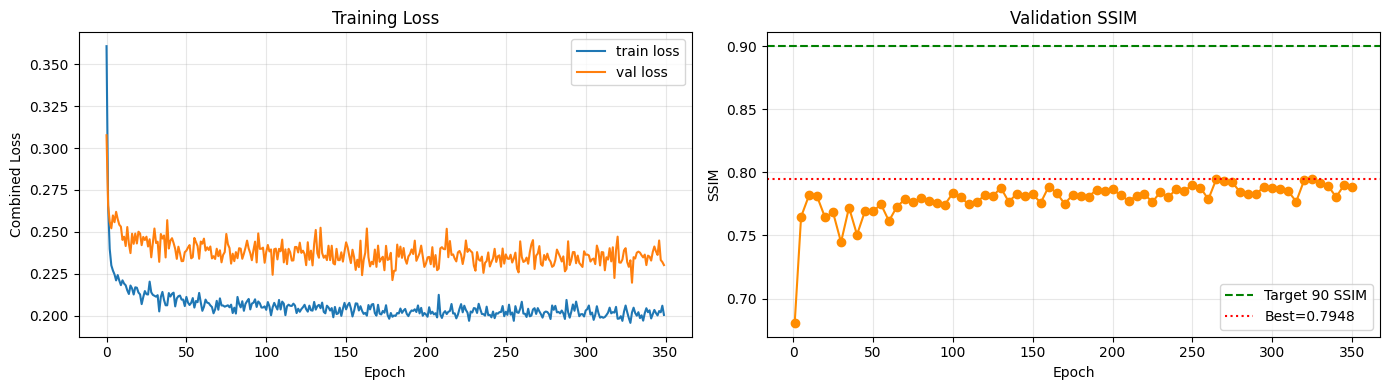

In [16]:
# Loss + SSIM curves
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, label="train loss")
axes[0].plot(val_losses,   label="val loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Combined Loss")
axes[0].set_title("Training Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

if val_ssims:
    ep_list, ss_list = zip(*val_ssims)
    axes[1].plot(ep_list, ss_list, "o-", color="darkorange")
    axes[1].axhline(0.9, color="green", ls="--", label="Target 90 SSIM")
    axes[1].axhline(best_ssim, color="red", ls=":", label=f"Best={best_ssim:.4f}")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("SSIM")
    axes[1].set_title("Validation SSIM"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Visual check on test subject using best-SSIM model

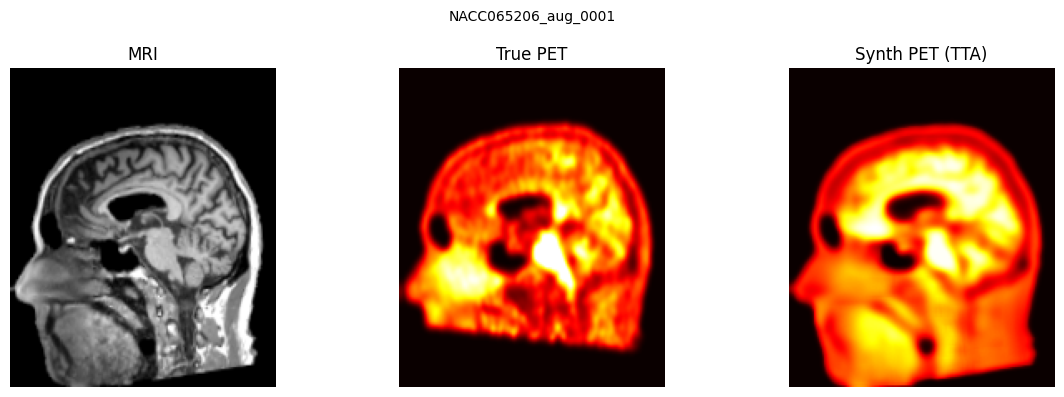


────────────────────────────────────────────────────────────
  NACC065206_aug_0001  (TTA=8 flips)
────────────────────────────────────────────────────────────
Metric             Global   Brain-Only
────────────────────────────────────────────────────────────
  MAE             0.0567       0.1502
  MSE           0.013895     0.037817
  SSIM            0.7781       0.7930


In [19]:
from skimage.metrics import structural_similarity as sk_ssim

model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

mri_path, pet_path = te_pairs[0]
mri_np     = norm_mri(np.load(mri_path))
pet_np     = norm_pet(np.load(pet_path))
brain_mask = compute_brain_mask(mri_np)

# TTA=True for final evaluation — uses 8-fold flip ensemble
syn_np = sliding_window_infer(model, mri_np, tta=True)
D, H, W = syn_np.shape
mid     = D // 2

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(mri_np[mid], cmap='gray');  axes[0].set_title('MRI');                axes[0].axis('off')
axes[1].imshow(pet_np[mid], cmap='hot');   axes[1].set_title('True PET');           axes[1].axis('off')
axes[2].imshow(syn_np[mid], cmap='hot');   axes[2].set_title('Synth PET (TTA)');    axes[2].axis('off')

sid = os.path.basename(os.path.dirname(mri_path))
plt.suptitle(sid, fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(SAMPLE_DIR, f'test_check_{sid}.png'), dpi=150)
plt.show()

m = compute_masked_metrics(syn_np, pet_np, brain_mask)
print(f"\n{'─'*60}")
print(f"  {sid}  (TTA=8 flips)")
print(f"{'─'*60}")
print(f"{'Metric':<14} {'Global':>10} {'Brain-Only':>12}")
print(f"{'─'*60}")
print(f"  {'MAE':<12}  {m['MAE']:>8.4f}   {m['MAE_brain']:>10.4f}")
print(f"  {'MSE':<12}  {m['MSE']:>8.6f}   {m['MSE_brain']:>10.6f}")
print(f"  {'SSIM':<12}  {m['SSIM']:>8.4f}   {m['SSIM_brain']:>10.4f}")


## Full evaluation on all test subjects

In [18]:
from skimage.metrics import structural_similarity as sk_ssim

model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

out_dir = "/workspace/Outputs/mri2pet_v3/eval_outputs"
os.makedirs(out_dir, exist_ok=True)

rows = []

for mri_path, pet_path in te_pairs:
    sid        = os.path.basename(os.path.dirname(mri_path))
    mri_np     = norm_mri(np.load(mri_path))
    pet_np     = norm_pet(np.load(pet_path))
    brain_mask = compute_brain_mask(mri_np)

    # TTA=True for final test evaluation
    syn_np = sliding_window_infer(model, mri_np, tta=True)
    m = compute_masked_metrics(syn_np, pet_np, brain_mask)
    rows.append({'subject': sid, **m})

    # Save visualisation — axial / coronal / sagittal × 3 rows
    D, H, W = pet_np.shape
    fig, axes = plt.subplots(3, 3, figsize=(13, 12))
    views = [
        (mri_np[D//2],  mri_np[:, H//2, :], mri_np[:, :, W//2]),
        (pet_np[D//2],  pet_np[:, H//2, :], pet_np[:, :, W//2]),
        (syn_np[D//2],  syn_np[:, H//2, :], syn_np[:, :, W//2]),
    ]
    row_labels = ['Real MRI', 'Real PET', 'Synth PET (TTA)']
    col_labels = ['Axial', 'Coronal', 'Sagittal']
    cmaps      = ['gray', 'hot', 'hot']

    for r, (row_imgs, rl, cm) in enumerate(zip(views, row_labels, cmaps)):
        for c, (img, cl) in enumerate(zip(row_imgs, col_labels)):
            ax = axes[r][c]
            ax.imshow(img, cmap=cm, vmin=0, vmax=1)
            ax.axis('off')
            if c == 0:
                ax.set_ylabel(rl, fontsize=9, color=['blue','red','green'][r],
                              fontweight='bold', rotation=90, labelpad=4)
                ax.yaxis.set_label_position('left')
                ax.set_yticks([])
            if r == 0:
                ax.set_title(cl, fontsize=10, fontweight='bold')

    plt.suptitle(
        f'{sid}\n'
        f'SSIM(global)={m["SSIM"]:.4f}  SSIM(brain)={m["SSIM_brain"]:.4f}'
        f'  MAE(brain)={m["MAE_brain"]:.4f}  MSE(brain)={m["MSE_brain"]:.6f}',
        fontsize=9
    )
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, f'{sid}_comparison.png'), dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f'  {sid}  SSIM(brain)={m["SSIM_brain"]:.4f}  MAE(brain)={m["MAE_brain"]:.4f}')

# Aggregate stats 
df = pd.DataFrame(rows)
print('\n── Per-subject metrics ──')
cols = ['subject','MAE','MSE','SSIM','MAE_brain','MSE_brain','SSIM_brain']
print(df[cols].to_string(index=False))
print('\n── Aggregate (mean ± std) ──')
numeric_cols = ['MAE','MSE','SSIM','MAE_brain','MSE_brain','SSIM_brain']
print(df[numeric_cols].describe().round(4).loc[['mean','std','min','max']].to_string())
print(f'\nCSV → {out_dir}/metrics_summary.csv')
df.to_csv(f'{out_dir}/metrics_summary.csv', index=False)


  NACC065206_aug_0001  SSIM(brain)=0.7930  MAE(brain)=0.1502
  NACC065206_aug_0002  SSIM(brain)=0.7930  MAE(brain)=0.1585
  NACC065206_aug_0003  SSIM(brain)=0.7922  MAE(brain)=0.1471
  NACC065206_aug_0004  SSIM(brain)=0.7925  MAE(brain)=0.1533
  NACC065206_aug_0005  SSIM(brain)=0.7894  MAE(brain)=0.1572
  NACC065206_aug_0006  SSIM(brain)=0.7924  MAE(brain)=0.1525
  NACC065206_aug_0007  SSIM(brain)=0.7900  MAE(brain)=0.1562
  NACC065206_aug_0008  SSIM(brain)=0.7941  MAE(brain)=0.1496
  NACC065206_orig  SSIM(brain)=0.6144  MAE(brain)=0.3174
  NACC072218_aug_0001  SSIM(brain)=0.8467  MAE(brain)=0.1102
  NACC072218_aug_0002  SSIM(brain)=0.8692  MAE(brain)=0.1112
  NACC072218_aug_0003  SSIM(brain)=0.8519  MAE(brain)=0.1116
  NACC072218_aug_0004  SSIM(brain)=0.8283  MAE(brain)=0.1117
  NACC072218_aug_0005  SSIM(brain)=0.8504  MAE(brain)=0.1127
  NACC072218_aug_0006  SSIM(brain)=0.8283  MAE(brain)=0.1116
  NACC072218_aug_0007  SSIM(brain)=0.8468  MAE(brain)=0.1132
  NACC072218_aug_0008  SSIM(